# NumPy - Multidimensional data arrays

The NumPy library is used for all numerical data analytic computations in Python.
It is a package that provides high-performance vector, matrix and higher-dimensional
data structures for Python. It is implemented in C and Fortran, so when calculations
are vectorized (formulated with vectors and matrices), performance is very good. 

To use NumPy we need to start by importing the NumPy library.  You can
import the module namespace as usual

```python
import numpy
```

though by convention, scripts and notebooks that perform a lot of NumPy
computations will often import NumPy with an alias as follows

In [1]:
import numpy as np

We will follow this convention and import numpy using the alias `np` for use
in all of our notebooks for this class.

This notebook lecture is using materials from past versions of this course
(see the archive).  We have also based many of our new examples on
the
[Quickstart tutorial](https://numpy.org/doc/stable/user/quickstart.html)
provided by the official NumPy library maintainers website.

# The Basics

NumPy's main object is the homogeneous multidimensional array.  It is a table
of elements (usually numbers), all of the same type, indexed by a tuple
of non-negative integers. 

Because the main NumPy array is a homogeneous collection of elements, it
is more similar to plain arrays you may be familiar with from C or Java, than
the `List` type from the main Python language.  Homogeneous means
that all of the items in the array must be of the same type.  So typically
we will work with a homogeneous array of all floats or all int types for
various machine learning tasks.

 In NumPy dimensions are called **axes**. For example the coordinates of a point
 in 3D space `[1, 2, 1]` has one axis.  That axis has 3 elements in it, so we
 say it has a length of 3.  A table of values like this:
 
 ```python
 [[1., 2., 1.],
  [0., 1., 3.]]
```

is said to have 2 axes.  The first axis (the rows, and referred to numerically
as axis 0) has a length of 2 (e.g. there are 2 rows).  The second axis
(the columns, numerically referred to as axis 1) has a length of 3
(there are 3 columns).

The vast majority of the data we use in this class will be arranged in a table
like this with 2 axis, where each row holds a sample of data, and each column
represents an attribute of the sampled data.  For example, for an experiment
each row might hold the information for a participant or subject of the experiment,
while the columns might be attributes like the subject's age, weight, height,
and results like how they respond to the experiment.

Lots look at an example array in NumPy and some of its attributes.

In [2]:
# create an array with elements ranging from 0 to 14, and reshape into
# an array with 2 axis, with 3 rows in the axis 0 and 5 columns in the axis 1
a = np.arange(15).reshape(3,5)
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [3]:
a.ndim

2

In [4]:
a.shape

(3, 5)

In [5]:
a.size

15

In [6]:
a.dtype

dtype('int64')

In [7]:
a.itemsize

8

In [8]:
a.data

In [9]:
type(a)

numpy.ndarray

NumPy's array class is called `ndarray` as the last cell shows.  An `ndarray`
is a general n-dimensional array.

In the previous example we demonstrated many of the basic attributes of
a NumPy `ndarray`

- **ndarray.ndim**: The number of axes (or dimensions) of the array.  Our array
  has 2 dimensions, axis 0 (rows) and axis 1 (columns)
- **ndarray.shape**: The length of each dimension of the array.  Since we have 3
  rows and 5 columns, axis 0 has a length of 3 and axis 1 has a length of 5.
- **ndarray.size**: The total number of elements of the array, has to be equal to
  the product of the shape (e.g. $3 \times 5 = 15$ here).
- **ndarray.dtype**: The type of elements in the array.  `ndarray`'s are **homogeneous**
  which means all elements are of the same type, the type describe here.  You
  will often see types like this `int64`, where `int` is the basic type and
  the number 64 indicates the number of bits being used for the data type
  representation.
- **ndarray.itemsize**: The size in bytes of each element of the array.  Since
  a byte uses 8 bits, a size of 8 bytes here equals 64 bits of memory for each of
  the 15 elements in the array.
- **ndarray.data**: The actually pointer to the buffer in memory holding the values
  of this array.  We don't normally access this directly.
  
Another quick example of an array, compare this one to the first one.

In [10]:
# set the display options so that our arrays are displayed as decimal notation
# rather than floating point notation in the rest of the notebook
np.set_printoptions(suppress=True)

In [11]:
# an array of random floating point numbers that range from -5 to 5
# the 3rd parameter, a tuple, gives the shape of the array to randomly create

# I think of this as axis 0 is the number of regular 2-d tables, so here we have
# 5 tables, where each table has 4 rows and 3 columns
b = np.random.uniform(-5.0, 5.0, (5, 4, 3))
b

array([[[ 0.5765947 ,  3.7386812 ,  2.26809791],
        [ 4.12335746,  0.38977068,  2.04413628],
        [ 4.34094338,  2.60227113,  0.57050691],
        [ 1.86497266,  2.73820324, -3.99618994]],

       [[-0.61008535,  0.79049533, -0.71132613],
        [-4.74694447, -0.20700249,  0.01880385],
        [-4.31163549, -3.54485154,  0.61227558],
        [-1.05822453, -4.30561418,  3.92863637]],

       [[ 3.11019071,  4.86545205,  2.65198468],
        [-3.25114255,  0.45849552, -4.16417001],
        [-4.94816774, -3.53908169, -4.0046457 ],
        [ 0.89298172, -0.92156469,  1.08673327]],

       [[-4.87075353,  3.90092306,  1.27368822],
        [ 4.92201454,  4.42165706,  3.07590888],
        [ 2.4692841 , -0.58071147,  3.6187562 ],
        [-2.3977157 , -3.63817618, -3.00114897]],

       [[ 2.48900993,  1.0322637 , -1.76725761],
        [-4.17425665,  2.83160377,  3.40639321],
        [-2.82696645, -4.03501705,  3.00253742],
        [-4.51748727,  4.29281931, -2.50007137]]])

In [12]:
b.ndim

3

In [13]:
b.shape

(5, 4, 3)

In [14]:
b.size

60

In [15]:
b.dtype

dtype('float64')

In [16]:
b.itemsize

8

# Array creation

There are a number of ways to create a NumPy `ndarray`.  We saw two
array generation functions in the previous example, one creating
an array with a range of values, and another using the NumPy `random`
submodule to generate arrays of random values.

One basic way to create an array is by initializing it form a regular
Python list or tuple.

In [17]:
a = np.array([2, 3, 4])
print(a)
print(a.dtype)
print(a.shape)

[2 3 4]
int64
(3,)


In [18]:
b = np.array([[1.2, 3.5, 5.1], 
              [3.8, 4.6, 2.7]])
print(b)
print(b.dtype)
print(b.shape)

[[1.2 3.5 5.1]
 [3.8 4.6 2.7]]
float64
(2, 3)


In [19]:
c = np.array(['gouda', 42, False, 3-2j])
print(c)
print(c.dtype)
print(c.shape)

['gouda' '42' 'False' '(3-2j)']
<U64
(4,)


Notice that when you give a nonhomogeneous list of values, NumPy will convert to
the most general type, which is this case is a string representation of each element
with a maximum length of 6 characters for each string.

We saw an example of array `b` where a sequence of lists is transformed into
an array with 2 axis.  This can be done for 3 or even higher numbers of axis, though
of course it gets complicated to construct such a list by hand in python.

The type of the array can be explicitly specified at creation time.

In [20]:
d = np.array( [[1, 2], [3, 4]], dtype=complex)
print(d)
print(d.dtype)
print(d.shape)

[[1.+0.j 2.+0.j]
 [3.+0.j 4.+0.j]]
complex128
(2, 2)


## Array generation functions

We saw some array generating functions above.  The `arange()` function
is analogous to the `range()` built-in funciton, it creates arrays with
1 axis with a range of values.

In [21]:
# array of values from 0 up to by not including 12
np.arange(12)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [22]:
# range of event values from 10 to 50 
np.arange(10, 51, 2)

array([10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42,
       44, 46, 48, 50])

In [23]:
# stepping backwards
np.arange(100, -1, -5)

array([100,  95,  90,  85,  80,  75,  70,  65,  60,  55,  50,  45,  40,
        35,  30,  25,  20,  15,  10,   5,   0])

Another function for generating sequences that might be more useful in this
class is `linspace()`.  This function can be used to generate an array of
a particular size with points linearly spaces over some range.  For example

In [24]:
# 10 point linearly spaces from 0.0 to 1.0
# notice that this funciton is inclusive of the endpoints, the first and last points
# will begin and end at the stated begin and end of the range
np.linspace(0.0, 1.0, 10)

array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])

In [25]:
# 100 points linearly spaces from -10 to 10
np.linspace(-10.0, 10.0, 100)

array([-10.        ,  -9.7979798 ,  -9.5959596 ,  -9.39393939,
        -9.19191919,  -8.98989899,  -8.78787879,  -8.58585859,
        -8.38383838,  -8.18181818,  -7.97979798,  -7.77777778,
        -7.57575758,  -7.37373737,  -7.17171717,  -6.96969697,
        -6.76767677,  -6.56565657,  -6.36363636,  -6.16161616,
        -5.95959596,  -5.75757576,  -5.55555556,  -5.35353535,
        -5.15151515,  -4.94949495,  -4.74747475,  -4.54545455,
        -4.34343434,  -4.14141414,  -3.93939394,  -3.73737374,
        -3.53535354,  -3.33333333,  -3.13131313,  -2.92929293,
        -2.72727273,  -2.52525253,  -2.32323232,  -2.12121212,
        -1.91919192,  -1.71717172,  -1.51515152,  -1.31313131,
        -1.11111111,  -0.90909091,  -0.70707071,  -0.50505051,
        -0.3030303 ,  -0.1010101 ,   0.1010101 ,   0.3030303 ,
         0.50505051,   0.70707071,   0.90909091,   1.11111111,
         1.31313131,   1.51515152,   1.71717172,   1.91919192,
         2.12121212,   2.32323232,   2.52525253,   2.72

The  `np.random.uniform()` function we used before shows a common pattern for many other
array generating functions.  Functions in NumPy's random library can be used
to generate arrays of random numbers with different distributions (uniform,
normal, gaussian distribution, etc).  The 3rd parameter is a tuple indicating
the shape of the array to be generated.

Often we know what shape of array we need and the type of the values that will
be in it, but we will generate the data later.  We can use functions
like `zeros()` or `empty()` to create empty arrays of a particular shape and type.

In [26]:
# array of zeros with 3 rows and 4 columns
a = np.zeros( (3, 4) )
print(a)
print(a.shape)
print(a.dtype)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
(3, 4)
float64


Notice that if you don't specify a datatype, many array generation functions default
to generating arrays of floating point numbers (with the standard number of bits 
for a float type used).

`zeros()` is useful if you need to ensure all values are initially 0, but if
you know you will be filling in all values, you can just get an empty array.
This sometimes has all 0's anyway, but the memory is not initialized so garbage
values can also be in the array you get back using `empty()`.

In [27]:
# empty array of  3 rows and 4 columns
a = np.empty( (6, 8) )
print(a)
print(a.shape)
print(a.dtype)

[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]
(6, 8)
float64


There are many other
[array generation functions](https://numpy.org/doc/stable/reference/routines.array-creation.html) 
that can be used.  

# Basic operations (Vectorized computations)

NumPy arrays support a style of programming known as vectorized computations,
first popularized in the Matlab programming enviornment (I believe).

What this means is that, instead of using loops to access and perform
operations on the elements of an array, we can treat an array as a single
value/variable and apply an operation to all elements with a single statement.

An example should make this clearer.

## Elementwise arithemetic

For example, you can easily apply simple operations to all elements of an array,
like addition or multiplication, by performing a scalar operation with an
`ndarray` object.  A **scalar** value is simply a fancy way of saying a
single value, e.g. a regular Python variable holding 1 value, instead of an
array that holds many values.

So any array we have we can perform element-wise scalar operations on it.

In [28]:
# 100 random integers in range from 1 to 10
a = np.random.randint(1,11,(10,10))
a

array([[10,  4,  7,  3,  5, 10, 10,  2,  7, 10],
       [10,  3,  5,  8, 10,  8,  4,  2,  6,  8],
       [ 1,  2,  2,  8,  2,  6,  3, 10,  9,  2],
       [ 9,  5,  9,  6, 10,  9,  3, 10,  8, 10],
       [ 2,  3, 10,  4,  8,  8,  7,  7,  7,  1],
       [ 1,  7,  6, 10,  1,  7,  6,  9, 10,  8],
       [ 4,  1,  2,  6,  7,  4,  2,  4, 10,  1],
       [10,  9,  5,  4,  1, 10,  6,  8, 10,  9],
       [ 6,  4,  1,  6,  8,  1,  5,  9, 10,  9],
       [ 2,  5,  1,  6,  2,  7,  4,  8,  2,  7]])

In [29]:
# subtract 10 from each element of array using vectorized operation
a - 10

array([[ 0, -6, -3, -7, -5,  0,  0, -8, -3,  0],
       [ 0, -7, -5, -2,  0, -2, -6, -8, -4, -2],
       [-9, -8, -8, -2, -8, -4, -7,  0, -1, -8],
       [-1, -5, -1, -4,  0, -1, -7,  0, -2,  0],
       [-8, -7,  0, -6, -2, -2, -3, -3, -3, -9],
       [-9, -3, -4,  0, -9, -3, -4, -1,  0, -2],
       [-6, -9, -8, -4, -3, -6, -8, -6,  0, -9],
       [ 0, -1, -5, -6, -9,  0, -4, -2,  0, -1],
       [-4, -6, -9, -4, -2, -9, -5, -1,  0, -1],
       [-8, -5, -9, -4, -8, -3, -6, -2, -8, -3]])

In [30]:
# multiple each array element by 10
10 * a

array([[100,  40,  70,  30,  50, 100, 100,  20,  70, 100],
       [100,  30,  50,  80, 100,  80,  40,  20,  60,  80],
       [ 10,  20,  20,  80,  20,  60,  30, 100,  90,  20],
       [ 90,  50,  90,  60, 100,  90,  30, 100,  80, 100],
       [ 20,  30, 100,  40,  80,  80,  70,  70,  70,  10],
       [ 10,  70,  60, 100,  10,  70,  60,  90, 100,  80],
       [ 40,  10,  20,  60,  70,  40,  20,  40, 100,  10],
       [100,  90,  50,  40,  10, 100,  60,  80, 100,  90],
       [ 60,  40,  10,  60,  80,  10,  50,  90, 100,  90],
       [ 20,  50,  10,  60,  20,  70,  40,  80,  20,  70]])

In [31]:
# divide all elemsnt by 10, result should be floats in range 0.1 to 1.0
a / 10

array([[1. , 0.4, 0.7, 0.3, 0.5, 1. , 1. , 0.2, 0.7, 1. ],
       [1. , 0.3, 0.5, 0.8, 1. , 0.8, 0.4, 0.2, 0.6, 0.8],
       [0.1, 0.2, 0.2, 0.8, 0.2, 0.6, 0.3, 1. , 0.9, 0.2],
       [0.9, 0.5, 0.9, 0.6, 1. , 0.9, 0.3, 1. , 0.8, 1. ],
       [0.2, 0.3, 1. , 0.4, 0.8, 0.8, 0.7, 0.7, 0.7, 0.1],
       [0.1, 0.7, 0.6, 1. , 0.1, 0.7, 0.6, 0.9, 1. , 0.8],
       [0.4, 0.1, 0.2, 0.6, 0.7, 0.4, 0.2, 0.4, 1. , 0.1],
       [1. , 0.9, 0.5, 0.4, 0.1, 1. , 0.6, 0.8, 1. , 0.9],
       [0.6, 0.4, 0.1, 0.6, 0.8, 0.1, 0.5, 0.9, 1. , 0.9],
       [0.2, 0.5, 0.1, 0.6, 0.2, 0.7, 0.4, 0.8, 0.2, 0.7]])

## Vectorized functions (Universal Functions)

Many functions have been provided in NumPy to perform vectorized operations
on NumPy arrays.  These are also called Universal functions (ufunc).

For example, all of the math function in the standard `math` library are
scalar functions, the expect a single value.  NumPy provides vectorized
versions of all of the math functions that performs the element-wise
operation on all of the values.
[NumPy mathematical functions reference](https://numpy.org/doc/stable/reference/routines.math.html)
These are all in the top NumPy namespace.  So for example


In [32]:
# array of random numbers in range -2pi to 2pi
b = np.random.uniform(-np.pi, np.pi, (10,10))
b

array([[ 1.31229404, -0.67502477, -1.54562027, -2.02116627, -0.76730126,
         0.11266421,  0.71942338,  2.11592079,  0.70695814,  1.33026702],
       [ 1.94983356, -1.29411433, -0.66610558,  0.78980222,  0.28042994,
         0.67096613, -0.7593628 ,  1.30876253,  2.0937695 , -1.18918312],
       [ 2.42226355,  0.38412709,  2.16670809, -1.9651155 , -2.4969846 ,
        -1.72570957,  2.29303398, -2.77819039, -0.67271186,  1.43976464],
       [ 2.92491682, -3.10856259, -0.67610264,  2.86162034,  1.42683453,
         1.87451336, -0.3417805 , -1.3610022 ,  2.39187342,  2.08441256],
       [ 1.77522182, -1.00210734,  2.53472065, -1.93430669,  1.49546852,
        -0.26042228,  2.30078744, -3.116265  ,  2.78867968, -1.74824192],
       [ 0.75170676, -1.75337486, -1.72377775,  3.13111711, -0.46428976,
         1.96419854,  2.11152404,  0.91698694,  1.93086226,  1.98475523],
       [ 0.90885156, -0.88140903,  0.55153295,  1.21926619, -0.45365933,
         2.37530413, -2.73093077, -1.85290647

In [33]:
# sin of each value
np.sin(b)

array([[ 0.96677393, -0.62491665, -0.9996831 , -0.90028613, -0.69419526,
         0.11242602,  0.65895105,  0.85506276,  0.64952393,  0.97121202],
       [ 0.92902131, -0.96196709, -0.61792876,  0.71021405,  0.27676882,
         0.62174297, -0.68845944,  0.96586513,  0.86633804, -0.92806506],
       [ 0.65888014,  0.37474998,  0.8276371 , -0.92325834, -0.60088519,
        -0.98802492,  0.75032838, -0.35545636, -0.62310932,  0.99142762],
       [ 0.21498437, -0.03302405, -0.62575778,  0.27632904,  0.98965538,
         0.95423143, -0.33516513, -0.97807381,  0.6814333 ,  0.87097344],
       [ 0.97917777, -0.84260772,  0.5703008 , -0.93465445,  0.9971642 ,
        -0.25748861,  0.74518033, -0.02532495,  0.34563271, -0.9842978 ],
       [ 0.68288658, -0.98337879, -0.98832115,  0.01047535, -0.44778786,
         0.92361023,  0.85733431,  0.79377264,  0.93587359,  0.91553558],
       [ 0.78879837, -0.77163588,  0.52399349,  0.93884693, -0.43825765,
         0.69346594, -0.39921627, -0.96047015

In [34]:
# logarithm of each value, need to take absolute value because logarithm
# not defined for negative values
np.log(np.abs(b))

array([[ 0.27177678, -0.3930059 ,  0.4354253 ,  0.70367471, -0.26487577,
        -2.18334346, -0.32930526,  0.74949008, -0.34678382,  0.28537969],
       [ 0.66774402,  0.25782654, -0.40630709, -0.23597272, -1.27143134,
        -0.39903662, -0.27527562,  0.26908206,  0.73896603,  0.17326662],
       [ 0.88470245, -0.95678182,  0.77320901,  0.67555102,  0.91508384,
         0.54563831,  0.82987582,  1.02179978, -0.39643818,  0.36447965],
       [ 1.07326604,  1.13416043, -0.39141037,  1.05138802,  0.35545837,
         0.62834909, -1.07358657,  0.30822134,  0.87207692,  0.73448707],
       [ 0.57392538,  0.00210512,  0.93008344,  0.65974896,  0.40243955,
        -1.34545082,  0.83325143,  1.13663517,  1.02556825,  0.55861066],
       [-0.28540898,  0.56154242,  0.54451825,  1.14138984, -0.76724644,
         0.6750843 ,  0.74740998, -0.08666204,  0.65796667,  0.6854956 ],
       [-0.0955735 , -0.12623348, -0.5950537 ,  0.1982492 , -0.79040873,
         0.86512548,  1.00464249,  0.61675547

So far all of the previous examples have applied a scalar or a function
transformation to each element of an array.

Operations between 2 arrays are also defined, and by default perform element-wise
operations.  They are defined normally when the arrays are of the same shape.
An example should make this clearer.

In [35]:
# arrays of same size and shape
a = np.array([1, 5, 7, 9])
b = np.array([-1, 4, -10, 6])

In [36]:
a + b

array([ 0,  9, -3, 15])

In [37]:
a - b

array([ 2,  1, 17,  3])

In some vectorized languages, multiplication opeator `*` is defined to perform
matrix multiplcation by default.  For NumPy arrays, it performs elementwise
multiplication by default.

In [38]:
A = np.array( [ [1, 1],
                [0, 1] ])

B = np.array( [ [2, 0],
                [3, 4] ])

# this is just the element-wise product of the two matrices
A * B

array([[2, 0],
       [0, 4]])

If you need true matrix multiplication, the `@` operator has been overloaded
in recent versions of NumPy for matrix multiplication, or you can use the
`np.dot()` function which computes the dot product, another name for matrix
multiplication.

In [39]:
# matrix multiplication
A @ B

array([[5, 4],
       [3, 4]])

In [40]:
# also the dot() member function performs matrix multiplication
A.dot(B)

array([[5, 4],
       [3, 4]])

## Combining vectorized operations

In the previous examples we  showed that element-wise vectorized operations can be chained.
The result of taking the absolute value of the matrix was then fed to the
`log()` function, so we applied absolute value followed by log function
operations successively to each value of array b.

We also showed that when 2 arrays are used on both sides of an operation, the
result is an element-wise vectorized operation.

In general more complex vectorized expressions can be built up by composing
many basic vectorized operations together.  So for example, jumping ahead a bit,
but a very common thing we might do is something like the following.

In [41]:
# x values range from -4 to 4
x = np.linspace(-4.0, 4.0, 1000)

Calculate and display function

$$
f(x) = 50 \sin(x^2) + \frac{1}{2} x^3 - 10 \cos(\frac{x}{2})
$$

In [42]:
# calculate the function f(x) composed of element-wise transformations
y = 50.0 * np.sin(x**2.0) + 0.5 * x**3.0 - 10.0 * np.cos(x/2.0)

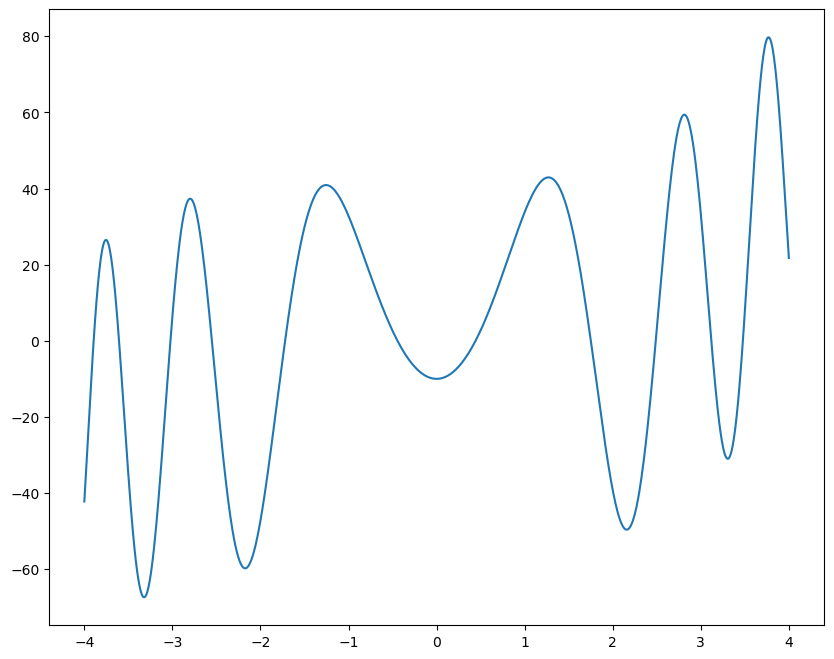

In [43]:
# display the resulting function as a plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
plt.plot(x, y);

## Array member functions

In addition to many universal functions (like the vectorized math
functions) provided by NumPy, there are many member functions of
an array itself that we will use.  These member functions
are sometimes known as unary operations.
[ndarray member function reference](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.html)

A few examples of some useful array member functions.

In [44]:
# array of random integers
a = np.random.randint(1, 6, (3,6))
a

array([[2, 5, 2, 4, 5, 1],
       [2, 3, 2, 3, 1, 3],
       [5, 4, 5, 3, 1, 2]])

In [45]:
# minimum value of the array
a.min()

1

In [46]:
# minimum of each column, use axis=0
a.min(axis=0)

array([2, 3, 2, 3, 1, 1])

In [47]:
# minimum of each row, use axis=1
a.min(axis=1)

array([1, 1, 1])

In [48]:
# mean of all values
a.mean()

2.9444444444444446

In [49]:
# sum of all values
a.sum()

53

In [50]:
# sum of each column
a.sum(axis=0)

array([ 9, 12,  9, 10,  7,  6])

In [51]:
# reshape the array
a.reshape( (6,3) )

array([[2, 5, 2],
       [4, 5, 1],
       [2, 3, 2],
       [3, 1, 3],
       [5, 4, 5],
       [3, 1, 2]])

In [52]:
a.reshape( (2,3,3) )

array([[[2, 5, 2],
        [4, 5, 1],
        [2, 3, 2]],

       [[3, 1, 3],
        [5, 4, 5],
        [3, 1, 2]]])

In [53]:
a.flatten()

array([2, 5, 2, 4, 5, 1, 2, 3, 2, 3, 1, 3, 5, 4, 5, 3, 1, 2])

## Elementwise logical expressions

Logical expressions work element-wise for NumPy arrays, just like numerical
expressions.  The result will be an array of boolean values.

So for example you can use the logical operators like `<`, `>=`, `==`, etc.
to get a result of booleans.

In [54]:
a

array([[2, 5, 2, 4, 5, 1],
       [2, 3, 2, 3, 1, 3],
       [5, 4, 5, 3, 1, 2]])

In [55]:
a == 1

array([[False, False, False, False, False,  True],
       [False, False, False, False,  True, False],
       [False, False, False, False,  True, False]])

In [56]:
a <= 2

array([[ True, False,  True, False, False,  True],
       [ True, False,  True, False,  True, False],
       [False, False, False, False,  True,  True]])

We will see later on when we perform boolean indexing how and why this
might be useful.

You can make more complex boolean expressions, however the logical operators
like `and` `or` and `not` do not work on arrays for element-wise boolean
expressions, so the following will fail if you want the locations in
a where the value is either a 1 or a 5.

In [57]:
try:
    (a == 1) or (a == 5)
except ValueError:
    print("ValueError was generated: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()")

ValueError was generated: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()


The error message here is misleading.  You should use the NumPy logical functions
to perform these operations, like this.

In [58]:
np.logical_or(a == 1, a == 5)

array([[False,  True, False, False,  True,  True],
       [False, False, False, False,  True, False],
       [ True, False,  True, False,  True, False]])

Also, though `and` and `or` were not overloaded to perform element-wise logical
comparison, instead the bitwise operators were overloaded for NumPy arrays
for this purpose.  These are the operators `&` for and `|` for or,
`~` for not and `^` for xor.  

So you will often commonly see these operators used instead to create logical
expressions between multiple NumPy arrays.

In [59]:
(a == 1) | (a == 5)

array([[False,  True, False, False,  True,  True],
       [False, False, False, False,  True, False],
       [ True, False,  True, False,  True, False]])

# Indexing, Slicing and Iterating

It is important you understand array slicing.  A one-dimensional array
can be indexed, sliced and iterated over in pretty much an identical
manner to lists and other Python sequences.

In [60]:
# a 1-dimensional array of 10 values
a = np.arange(10)**3
a

array([  0,   1,   8,  27,  64, 125, 216, 343, 512, 729])

In [61]:
# index the 3rd element at index 2
a[2]

8

In [62]:
# get a slice from element 2 to up to by not including element 5
a[2:5]

array([ 8, 27, 64])

In [63]:
# use step size to get even values from start up to element 6
a[:7:2]

array([  0,   8,  64, 216])

In [64]:
# reverse the array
a[::-1]

array([729, 512, 343, 216, 125,  64,  27,   8,   1,   0])

In [65]:
# iterate over elements in the array
for val in a:
    print(val**(1.0/3.0))

0.0
1.0
2.0
3.0
3.9999999999999996
4.999999999999999
5.999999999999999
6.999999999999999
7.999999999999999
8.999999999999998


Although as we noted in a previous video, there is one big difference between
arrays and regular Python sequences when it comes to slicing.

When you slice an array, you get a view of the array.

In [66]:
b = a[2:5]
b

array([ 8, 27, 64])

In [67]:
a[2:5] = 0
a

array([  0,   1,   0,   0,   0, 125, 216, 343, 512, 729])

In [68]:
b

array([0, 0, 0])

So notice by change the values to 0 in a, the view in b now also shows them as 0.

But be aware that some operations work in place, so the view will stay, but some
operations end up creating a new copy of the values.  For example.

In [69]:
# b is still a view
b[1] = 10
b

array([ 0, 10,  0])

In [70]:
# sow the change to a value of 10 shows up in a as well
a

array([  0,   1,   0,  10,   0, 125, 216, 343, 512, 729])

In [71]:
# operators +=, *=, etc. will work in place, so b remains a view of a
b += 5
b

array([ 5, 15,  5])

In [72]:
a

array([  0,   1,   5,  15,   5, 125, 216, 343, 512, 729])

In [73]:
# but performing the same operation again, but using just a regular assignment
# causes a copy to be made
b = b + 5
b

array([10, 20, 10])

In [74]:
a

array([  0,   1,   5,  15,   5, 125, 216, 343, 512, 729])

The lesson of the last example is you do have to be a bit careful.  I usually
assume slices will be views.  Making a view rather than a copy is done for
efficiency reasons.  A primary goal of NumPy is to provide efficient numerical
in memory calculations.  So copying arrays when evaluating results is avoided
if at all possible, thus views are the normal result from a slice.

## Multidimensional indexing and slicing

When your `ndarray` has 2 or more dimensions, you can still perform indexing
and slicing operations.  All of the same indexing and slicing syntax is
available on a NumPy array for every dimension of the array.

So for a multidimensional array you can have one indexing/slicing expression
per axis.  These indices are given in a tuple separated by commas.


In [75]:
# construct array as a function of each coordinate.  Since
# the array is 2 dimensional, the function will receive two coordinates,
# the row number and column number
def f(row, col):
    return 3*row + col**2

# create an 2-dimensional array of integers
b = np.fromfunction(f, (5,4), dtype=int)
b

array([[ 0,  1,  4,  9],
       [ 3,  4,  7, 12],
       [ 6,  7, 10, 15],
       [ 9, 10, 13, 18],
       [12, 13, 16, 21]])

In [76]:
# item at row 2, column 3
b[2,3]

15

In [77]:
# item at row 3, column 1
b[3,1]

10

We can extract a column or set of columns.  This is common if/when we want to
perform an operation on some attribute or feature of a data set.

In [78]:
# all rows, the column 1 only of them
b[0:5, 1]

array([ 1,  4,  7, 10, 13])

In [79]:
# since there are only 5 rows, this is equivalent to extract column 1
b[:, 1]

array([ 1,  4,  7, 10, 13])

Likewise we can extract rows.  This is common to get a subset of samples from
a data set.  

In [80]:
# extract rows 2 and 3, all columns
b[2:4, :]

array([[ 6,  7, 10, 15],
       [ 9, 10, 13, 18]])

If we want all columns, you can omit any final dimensions where you want all values
in them.  So to get rows 2 and 3 we simply do the following.  We will use this
type of slice frequently to extract samples from a table of data values we are
manipulating.

In [81]:
b[2:4]

array([[ 6,  7, 10, 15],
       [ 9, 10, 13, 18]])

We can get even more complex, like get the values in the middle and use
steps, which sometimes can be useful.

In [82]:
# the clip off first and last row and column to get middle values
b[1:-1, 1:-1]

array([[ 4,  7],
       [ 7, 10],
       [10, 13]])

In [83]:
# get every other row
b[::2]

array([[ 0,  1,  4,  9],
       [ 6,  7, 10, 15],
       [12, 13, 16, 21]])

In [84]:
# get every other column, start at column 1
b[:,1::2]

array([[ 1,  9],
       [ 4, 12],
       [ 7, 15],
       [10, 18],
       [13, 21]])

An notice like we did before for a single dimension, we can use a slice to
manipulate only the values in a row or column, or in general some slice.

In [85]:
# make column 2 be the negative of its current value
b[:,2] = -b[:,2]

# subtract 10 from values in row 3
b[3] -= 10

b

array([[  0,   1,  -4,   9],
       [  3,   4,  -7,  12],
       [  6,   7, -10,  15],
       [ -1,   0, -23,   8],
       [ 12,  13, -16,  21]])

We almost never iterate over NumPy arrays.  If you are iterating over a NumPy
array you are probably not using more efficient vectorized element-wise operations.

However, we can do it like we did for a single dimensional array.  If we do it for
the 2-dimensional array, we will iterate over each row 

In [86]:
for row in b:
    print(row)

[ 0  1 -4  9]
[ 3  4 -7 12]
[  6   7 -10  15]
[ -1   0 -23   8]
[ 12  13 -16  21]


If you want to iterate over every element, you can flatten the array using
either the `flatten()` method, or better use the `flat` attribute of arrays which
gives a 1-dimensional view into the array.

In [87]:
for element in b.flat:
    print(element)

0
1
-4
9
3
4
-7
12
6
7
-10
15
-1
0
-23
8
12
13
-16
21


If you want to iterate over columns, you can use an explicit index and slice it.

In [88]:
# extract number of cols in b
rows,cols = b.shape
for col in range(cols):
    print(b[:,col])

[ 0  3  6 -1 12]
[ 1  4  7  0 13]
[ -4  -7 -10 -23 -16]
[ 9 12 15  8 21]


# Reshaping and Stacking arrays

We already showed some examples of reshaping an array.  In general you can
always flatten an array to a one-dimensional vector if needed.  All
reshaping will always end up with the same number of elements, just shaped into
different dimensions.

In [89]:
b.shape

(5, 4)

In [90]:
b.flatten()

array([  0,   1,  -4,   9,   3,   4,  -7,  12,   6,   7, -10,  15,  -1,
         0, -23,   8,  12,  13, -16,  21])

In [91]:
# reshape as 3-dimenstional, 2 tables of 5 rows and 2 columns
b.reshape((2,5,2))

array([[[  0,   1],
        [ -4,   9],
        [  3,   4],
        [ -7,  12],
        [  6,   7]],

       [[-10,  15],
        [ -1,   0],
        [-23,   8],
        [ 12,  13],
        [-16,  21]]])

Several arrays can be stacked together along different axes.  The
size of the axis/dimension being stacked along will need to match for
the stacking to work.

In [92]:
a = np.random.randint(0, 5, (2,2))
a

array([[3, 4],
       [0, 3]])

In [93]:
b = np.random.randint(0, 5, (2,2))
b

array([[2, 4],
       [1, 1]])

In [94]:
# vertical stacking, put a on top of be
# notice you need to pass in the arrays as a tuple here, because you can actually
# stack 3 or more arrays of the same number of columns if you wish.
np.vstack((a,b))

array([[3, 4],
       [0, 3],
       [2, 4],
       [1, 1]])

In [95]:
# horizontal stacking, stack b beside a
np.hstack((a,b))

array([[3, 4, 2, 4],
       [0, 3, 1, 1]])

# Advanced Indexing and Index Tricks

NumPy offers more indexing facilities than regular Python sequences.
In addition to indexing by integers and slices (as we saw above), arrays
can be indexed by arrays of integers and arrays of booleans.

## Indexing with arrays of indices

If we have an array of indexes (also works with a regular Python sequence of 
indexes, like a list), we can use this to index into an array.

For example.

In [96]:
# use our 2-dimensional array b again from before 

# construct array as a function of each coordinate.  Since
# the array is 2 dimensional, the function will receive two coordinates,
# the row number and column number
def f(row, col):
    return 3*row + col**2

# create an 2-dimensional array of integers
b = np.fromfunction(f, (5,4), dtype=int)
b

array([[ 0,  1,  4,  9],
       [ 3,  4,  7, 12],
       [ 6,  7, 10, 15],
       [ 9, 10, 13, 18],
       [12, 13, 16, 21]])

In [97]:
# selection rows 1 3 and 4 only
rows = np.array([1,3,4])
b[rows]

array([[ 3,  4,  7, 12],
       [ 9, 10, 13, 18],
       [12, 13, 16, 21]])

In [98]:
# works with a regular python list as well
rows = [1, 3, 4]
b[rows]

array([[ 3,  4,  7, 12],
       [ 9, 10, 13, 18],
       [12, 13, 16, 21]])

In [99]:
# works to select columns
cols = [0, 2]
b[:,cols]

array([[ 0,  4],
       [ 3,  7],
       [ 6, 10],
       [ 9, 13],
       [12, 16]])

In [100]:
# and we can select only some columns from some rows.  But when you supply
# both an index for rows and columns, the lists must have the same shape
# so to get rows 1,3,4 and only the columns 0 and 2 from them we need
# to do something like this

# first start simply, get column 0 and 2 from row 1 only
rows = np.array([1, 1])
cols = np.array([0, 2])
b[rows,cols]

array([3, 7])

In [101]:
# now we want those columns from rows 1 and 3
# notice the arrays have to be of the same shape
rows = np.array([[1, 1],
                 [3, 3]])
cols = np.array([[0, 2],
                 [0, 2]])

b[rows,cols]

array([[ 3,  7],
       [ 9, 13]])

In [102]:
# finally what we really wanted, rows 1,3 and 4 but only columns 0 and 2.
# result of this is 3 rows and 2 columns, so our rows and columns
# indexes need to be 3x2 to match the shape we are trying to extract
rows = np.array([[1, 1],
                 [3, 3],
                 [4, 4]])
cols = np.array([[0, 2],
                 [0, 2],
                 [0, 2]])

b[rows,cols]

array([[ 3,  7],
       [ 9, 13],
       [12, 16]])

This latter example is less common, we almost always need some particular rows
or some particular columns.  And if you do need some rows and only some columns
from those rows, it can be easier to perform the slicing in two steps instead.

In [103]:
# first extract the sample rows
rows = [1, 3, 4]
samples = b[rows]
samples

array([[ 3,  4,  7, 12],
       [ 9, 10, 13, 18],
       [12, 13, 16, 21]])

In [104]:
# now keep only the attributes we need
cols = [0, 2]
samples = samples[:,cols]
samples

array([[ 3,  7],
       [ 9, 13],
       [12, 16]])

Here is a more complex example of using lists to index into an array.
We often might want to find the particular value in each row or column
that is special or of some interest.

Say we have a data set of 4 time dependent series.
Here each series is a row, and the column would represent the common sample
time in each case, e.g. t=0, 1, 2, 3, 4, 5, 6 (though we are just making
up some example data here).

In [105]:
# 4 time-dependent series sampled in each row of 7 time steps each
data = np.sin(np.arange(28)).reshape(4,7)
data

array([[ 0.        ,  0.84147098,  0.90929743,  0.14112001, -0.7568025 ,
        -0.95892427, -0.2794155 ],
       [ 0.6569866 ,  0.98935825,  0.41211849, -0.54402111, -0.99999021,
        -0.53657292,  0.42016704],
       [ 0.99060736,  0.65028784, -0.28790332, -0.96139749, -0.75098725,
         0.14987721,  0.91294525],
       [ 0.83665564, -0.00885131, -0.8462204 , -0.90557836, -0.13235175,
         0.76255845,  0.95637593]])

In [106]:
# index of maxima for each series,
# argmax returns the index where the maximum occurs, 
# using axis=1 means we get the index for each of our 4 sample rows where 
# maximum value occurs
ind = data.argmax(axis=1)
ind

array([2, 1, 0, 6])

In [107]:
# these are the indexes.  Say the columns refer to a sample of the time
# series starting at time 20 and going til time 120.  So the sample times
# represent a time being sampled at
time = np.linspace(20, 120, 7)
time

array([ 20.        ,  36.66666667,  53.33333333,  70.        ,
        86.66666667, 103.33333333, 120.        ])

In [108]:
# so we can use the indexes to find the actual time where the maximum
# occured for each time series sample
time[ind]

array([ 53.33333333,  36.66666667,  20.        , 120.        ])

## Indexing with boolean arrays

When we index arrays with arrays of (integer) indices we are providing the lit of
indices to pick.

With boolean indices the approach is different; we explicitly choose which items in the array we want and which ones we don't.

The most naturally way to think of and use boolean indexing is to use an array
of boolean values that has the *same shape* as the original array.

For example, we can create a boolean array using boolean operations, as we
discussed earlier.

In [109]:
b

array([[ 0,  1,  4,  9],
       [ 3,  4,  7, 12],
       [ 6,  7, 10, 15],
       [ 9, 10, 13, 18],
       [12, 13, 16, 21]])

In [110]:
# boolean array of those items divisible by 3
b % 3 == 0

array([[ True, False, False,  True],
       [ True, False, False,  True],
       [ True, False, False,  True],
       [ True, False, False,  True],
       [ True, False, False,  True]])

In [111]:
# use boolean indexing to extract only those values divisible by 3
b[ (b % 3 == 0) ]

array([ 0,  9,  3, 12,  6, 15,  9, 18, 12, 21])

You will notice the result will be a 1-dimensional vector, even though in this
case were selecting columns 0 and the last column, so we could have
wanted a `(5,2)` shaped result.

But this happens because a boolean selection can pick arbitrary values from
the array.  For example.

In [112]:
# notice you should not use and or or to boolean expressions between arrays, use &
# and | instead, or a.any() a.all()
(b >= 4) & (b <= 10)

array([[False, False,  True,  True],
       [False,  True,  True, False],
       [ True,  True,  True, False],
       [ True,  True, False, False],
       [False, False, False, False]])

In [113]:
# values between 4 and 10
b[ (b >= 4) & (b <= 10) ]

array([ 4,  9,  4,  7,  6,  7, 10,  9, 10])

Boolean indexing can be very useful for assignments, for example if we
want to zero-out all of the numbers divisible by 3


In [114]:
# assign something into the locations selected by our boolean index
b[ (b % 3 == 0) ] = 0
b

array([[ 0,  1,  4,  0],
       [ 0,  4,  7,  0],
       [ 0,  7, 10,  0],
       [ 0, 10, 13,  0],
       [ 0, 13, 16,  0]])

The second way of indexing with booleans is more similar to integer
indexing: for each dimension of the array we give a 1D boolean array selecting
the slices we want.

This implies that the boolean array has to have the same size as the size for the
dimension you are slicing on.

So we can get the same rows and columns we did previously but using
boolean indexing like the following.

In [115]:
# use our 2-dimensional array b again from before 

# construct array as a function of each coordinate.  Since
# the array is 2 dimensional, the function will receive two coordinates,
# the row number and column number
def f(row, col):
    return 3*row + col**2

# create an 2-dimensional array of integers
b = np.fromfunction(f, (5,4), dtype=int)
b

array([[ 0,  1,  4,  9],
       [ 3,  4,  7, 12],
       [ 6,  7, 10, 15],
       [ 9, 10, 13, 18],
       [12, 13, 16, 21]])

In [116]:
# select rows 1, 3 and 4 again but with a boolean index
rows = [False, True, False, True, True]
b[rows]

array([[ 3,  4,  7, 12],
       [ 9, 10, 13, 18],
       [12, 13, 16, 21]])

In [117]:
# select columns 0 and 2
cols = [True, False, True, False]
b[:,cols]

array([[ 0,  4],
       [ 3,  7],
       [ 6, 10],
       [ 9, 13],
       [12, 16]])